In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
from scipy.integrate import solve_ivp

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Physical parameters
g = 9.81      # gravity
L = 1.0       # pendulum length

In [4]:
# Differential equations
def pendulum(t, y):
    theta, omega = y

    dtheta_dt = omega
    domega_dt = -(g/L) * np.sin(theta)

    return [dtheta_dt, domega_dt]


In [5]:
# Initial conditions
theta0 = np.pi / 2    # 45 degrees
omega0 = 0.0

y0 = [theta0, omega0]

# Time interval
t_span = (0, 10)

# Times where solution is evaluated
t_eval = np.linspace(0, 10, 1000)

In [6]:
# Solve ODE
solution = solve_ivp(
    pendulum,
    t_span,
    y0,
    t_eval=t_eval
)


In [7]:
# Extract solution
theta = solution.y[0]
omega = solution.y[1]
time = solution.t

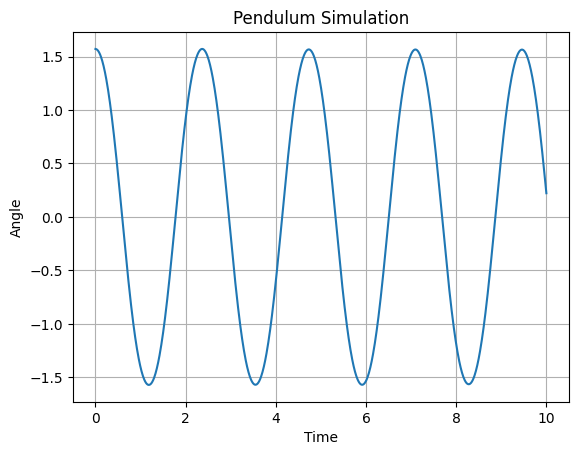

In [8]:
# Plot angle vs time
plt.plot(time, theta)

plt.xlabel("Time")
plt.ylabel("Angle")
plt.title("Pendulum Simulation")

plt.grid()

plt.show()

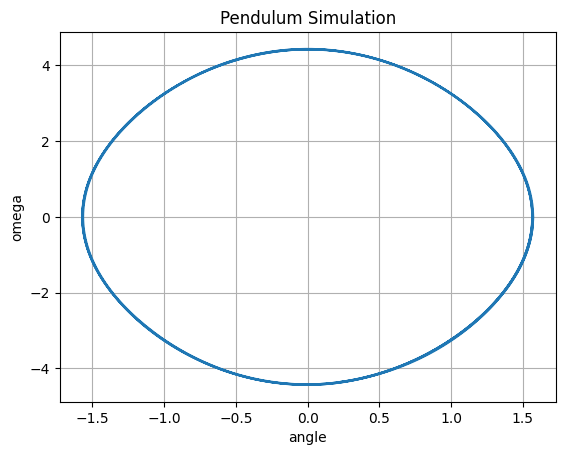

In [9]:
plt.plot(theta, omega)

plt.xlabel("angle")
plt.ylabel("omega")
plt.title("Pendulum Simulation")

plt.grid()

plt.show()


In [14]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [26]:

# Parameters
L = 50              # lattice size
J = 1.0             # coupling
T = 0.00001        # temperature
steps = 100000

# Random initial spins
spins = np.random.choice([-1, 1], size=(L, L))


In [27]:
# Periodic boundary conditions
def energy_change(i, j):

    s = spins[i, j]

    neighbors = (
        spins[(i+1)%L, j] +
        spins[(i-1)%L, j] +
        spins[i, (j+1)%L] +
        spins[i, (j-1)%L]
    )

    dE = 2 * J * s * neighbors

    return dE


In [28]:
# Monte Carlo simulation
for step in range(steps):

    # Choose random site
    i = np.random.randint(0, L)
    j = np.random.randint(0, L)

    dE = energy_change(i, j)

In [29]:
 # Metropolis rule
if dE < 0:
    spins[i, j] *= -1

else:
     probability = np.exp(-dE / T)

     if np.random.rand() < probability:
        spins[i, j] *= -1

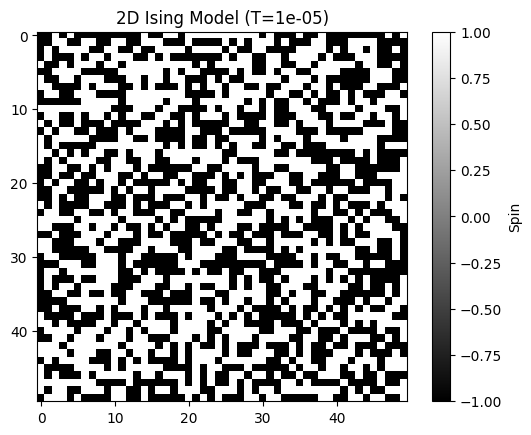

In [30]:
# Plot final configuration
plt.imshow(spins, cmap='gray')

plt.title(f"2D Ising Model (T={T})")

plt.colorbar(label="Spin")

plt.show()

In [31]:
M = np.mean(spins)

print("Magnetization =", M)

Magnetization = 0.0208
